# DQN Pairs Trading
OLS beta · custom gym · PyTorch DQN

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
from collections import deque
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from pairs_trading_env import PairsTradingEnv

# ── paste or import your env ──────────────────────────────────────────
# from pairs_trading_env import PairsTradingEnv
# If the file is in the same directory just uncomment the line above.
# Otherwise the full class is expected to be available as PairsTradingEnv.
# ─────────────────────────────────────────────────────────────────────

SEED = 12
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cpu


## 1 · Load data & compute OLS beta

length: 1065270
OLS  alpha=-0.0123  beta=0.7913
Spread  mean=-0.0438  std=0.9563


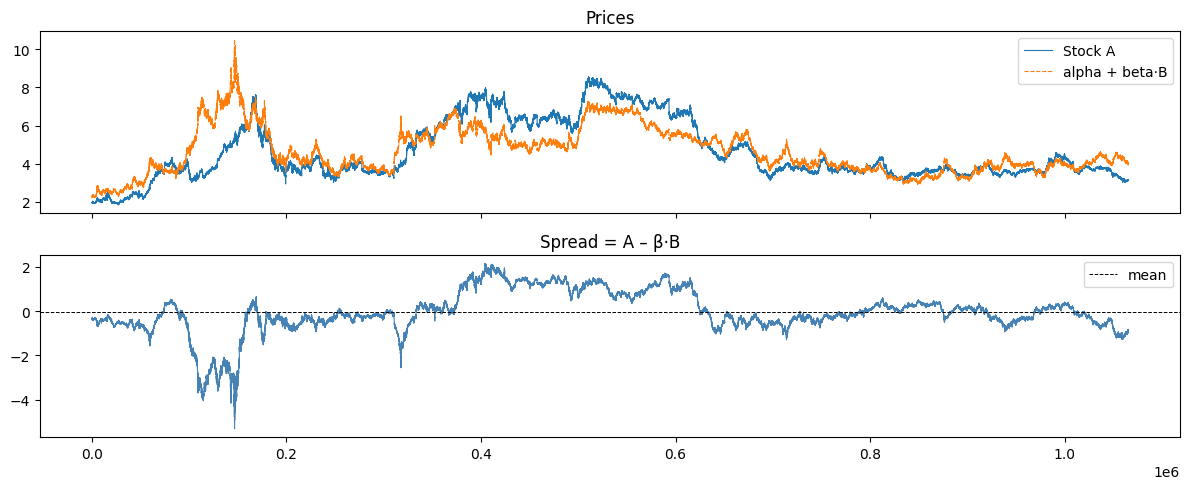

In [15]:
TRAIN_RATIO  = 0.80
# ── paths ─────────────────────────────────────────────────────────────
CSV_A = 'dataset/CORN_USD_2005_2020.csv'   # ← change to your file
CSV_B = 'dataset/WHEAT_USD_2005_2020.csv'   # ← change to your file
CSV_C = 'data-scripts/data.csv'
# ─────────────────────────────────────────────────────────────────────

df_a = pd.read_csv(CSV_A).dropna()
df_b = pd.read_csv(CSV_B).dropna()
# df_a = pd.read_csv(CSV_C)[['s1']].dropna()
# df_b = pd.read_csv(CSV_C)[['s2']].dropna()
# df_a = df_a.rename(columns={"s1": "close"})
# df_b = df_b.rename(columns={"s2": "close"})
# df_a = df_a[int(0*len(df_a)):int(len(df_a))]
# df_b = df_b[int(0*len(df_b)):int(len(df_b))]

# df_a = df_a[::20]
# df_b = df_b[::20]
n = len(df_a)
print(f"length: {n}")
# ── OLS: A = alpha + beta·B  →  beta = cov(A,B) / var(B) ────────────
A = df_a['close'].values
B = df_b['close'].values

split        = int(n * TRAIN_RATIO)
X = np.column_stack([np.ones(split), B[:split]])
beta_ols, _ = np.linalg.lstsq(X, A[:split], rcond=None)[0], None
alpha_ols = beta_ols[0]
beta      = beta_ols[1]
print(f'OLS  alpha={alpha_ols:.4f}  beta={beta:.4f}')

spread = A - beta * B
print(f'Spread  mean={spread.mean():.4f}  std={spread.std():.4f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(A, label='Stock A', linewidth=0.8)
axes[0].plot(beta * B + alpha_ols, label=f'alpha + beta·B', linewidth=0.8, linestyle='--')
axes[0].legend(); axes[0].set_title('Prices')
axes[1].plot(spread, linewidth=0.8, color='steelblue')
axes[1].axhline(spread.mean(), color='k', linestyle='--', linewidth=0.7, label='mean')
axes[1].set_title('Spread = A – β·B'); axes[1].legend()
plt.tight_layout(); plt.show()

## 2 · Train / test split

In [16]:

df_a_train, df_b_train = df_a.iloc[:split], df_b.iloc[:split]
df_a_test,  df_b_test  = df_a.iloc[split:].reset_index(drop=True), \
                          df_b.iloc[split:].reset_index(drop=True)

print(f'Train bars: {split}   Test bars: {n - split}')

Train bars: 852216   Test bars: 213054


## 3 · DQN components

In [17]:
# ── Hyper-parameters ──────────────────────────────────────────────────
TRANSACTION_COST = 0     # flat cost per open / close (unused)
INITIAL_CASH     = 100.0
TC               = 0.0001  # 0.01% per leg, applied in both train and test

GAMMA            = 0.99
LR               = 1e-3
BATCH_SIZE       = 64
MEMORY_SIZE      = 50_000
TARGET_UPDATE    = 200
N_EPISODES       = 50

EPS_START        = 1.00
EPS_END          = 0.02
EPS_DECAY        = 0.95
# ─────────────────────────────────────────────────────────────────────

STATE_DIM  = PairsTradingEnv.STATE_DIM   # 4
N_ACTIONS  = PairsTradingEnv.N_ACTIONS   # 3


# ── Q-Network ─────────────────────────────────────────────────────────
class QNet(nn.Module):
    def __init__(self, state_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ── Replay buffer ─────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (
            torch.tensor(np.array(s),  dtype=torch.float32, device=DEVICE),
            torch.tensor(a,            dtype=torch.long,    device=DEVICE),
            torch.tensor(r,            dtype=torch.float32, device=DEVICE),
            torch.tensor(np.array(s2), dtype=torch.float32, device=DEVICE),
            torch.tensor(d,            dtype=torch.float32, device=DEVICE),
        )

    def __len__(self): return len(self.buf)


# ── DQN agent ─────────────────────────────────────────────────────────
class DQNAgent:
    def __init__(self):
        self.policy_net = QNet(STATE_DIM, N_ACTIONS).to(DEVICE)
        self.target_net = QNet(STATE_DIM, N_ACTIONS).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.memory    = ReplayBuffer(MEMORY_SIZE)
        self.steps     = 0
        self.epsilon   = EPS_START

    def select_action(self, state: np.ndarray) -> int:
        if random.random() < self.epsilon:
            return random.randint(0, N_ACTIONS - 1)
        with torch.no_grad():
            t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            return int(self.policy_net(t).argmax(dim=1).item())

    def learn(self):
        if len(self.memory) < BATCH_SIZE:
            return

        s, a, r, s2, done = self.memory.sample(BATCH_SIZE)

        q_vals = self.policy_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            best_actions = self.policy_net(s2).argmax(dim=1, keepdim=True)
            q_next       = self.target_net(s2).gather(1, best_actions).squeeze(1)
            target       = r + GAMMA * q_next * (1 - done)

        loss = nn.SmoothL1Loss()(q_vals, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % TARGET_UPDATE == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(EPS_END, self.epsilon * EPS_DECAY)

## 4 · Training loop

In [18]:
def make_train_env():
    return PairsTradingEnv(
        df_a_train, df_b_train,
        beta          = beta,
        initial_cash  = INITIAL_CASH,
        tc            = TC,
    )

agent      = DQNAgent()
train_env  = make_train_env()

ep_returns = []

for ep in range(1, N_EPISODES + 1):
    obs  = train_env.reset()
    done = False
    ep_reward = 0.0

    while not done:
        action            = agent.select_action(obs)
        obs2, reward, done, _ = train_env.step(action)
        agent.memory.push(obs, action, reward, obs2, float(done))
        agent.learn()
        ep_reward += reward
        obs        = obs2

    agent.decay_epsilon()
    ep_returns.append(ep_reward)

    if ep % 10 == 0:
        recent = np.mean(ep_returns[-10:])
        print(f'Episode {ep:4d}/{N_EPISODES}  '
              f'return={ep_reward:+8.3f}  '
              f'avg10={recent:+8.3f}  '
              f'ε={agent.epsilon:.3f}  '
              f'mem={len(agent.memory)}')

print('Training complete.')

Episode   10/50  return=  -7.189  avg10=  -4.075  ε=0.599  mem=10000
Episode   20/50  return=  -3.320  avg10=  -2.298  ε=0.358  mem=20000
Episode   30/50  return=  -1.626  avg10=  -1.585  ε=0.215  mem=30000
Episode   40/50  return=  +0.345  avg10=  -0.257  ε=0.129  mem=40000
Episode   50/50  return=  -0.812  avg10=  -0.373  ε=0.077  mem=50000
Training complete.


### Training curves

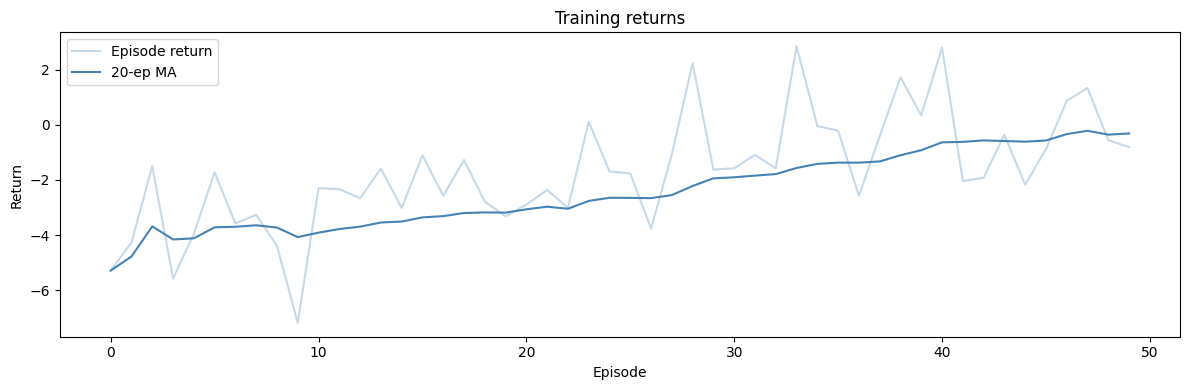

In [19]:
window = 20
roll   = pd.Series(ep_returns).rolling(window, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(ep_returns, alpha=0.3, color='steelblue', label='Episode return')
ax1.plot(roll,       color='steelblue', linewidth=1.5, label=f'{window}-ep MA')
ax1.set_ylabel('Return')
ax1.legend(loc='upper left')


ax1.set_title('Training returns'); ax1.set_xlabel('Episode')
plt.tight_layout(); plt.show()

## 5 · Evaluation on test set

In [20]:
def run_episode(env: PairsTradingEnv, agent: DQNAgent, greedy: bool = True):
    obs  = env.reset(is_test=True)
    done = False
    log  = []

    saved_eps = agent.epsilon
    if greedy:
        agent.epsilon = 0.0

    while not done:
        action = agent.select_action(obs)
        obs, reward, done, info = env.step(action)
        info['action'] = action
        info['reward'] = reward
        log.append(info)

    agent.epsilon = saved_eps
    return pd.DataFrame(log)

test_env = PairsTradingEnv(
    df_a_test, df_b_test,
    beta         = beta,
    initial_cash = INITIAL_CASH,
    tc           = TC,
)

log = run_episode(test_env, agent, greedy=True)

final_val    = log['portfolio_value'].iloc[-1]
total_return = final_val - INITIAL_CASH
pct_return   = total_return / INITIAL_CASH * 100
n_years      = len(log) / 66_579
ann_return   = (final_val / INITIAL_CASH) ** (1 / n_years) - 1 if final_val > 0 else float('nan')

pos_arr  = log['position'].values
n_trades = int((np.diff(pos_arr) != 0).sum())

print(f'TC per leg       : {TC*100:.3f}%')
print(f'Position changes : {n_trades:,}')
print(f'Total P&L        : {total_return:+.4f}  ({pct_return:+.1f}%)')
print(f'Final value      : {final_val:.4f}')
print(f'Annualised return: {ann_return*100:+.2f}%  over {n_years:.2f} years')

TC per leg       : 0.010%
Position changes : 9,573
Total P&L        : -49.0717  (-49.1%)
Final value      : 50.9283
Annualised return: -19.01%  over 3.20 years


### Test plots

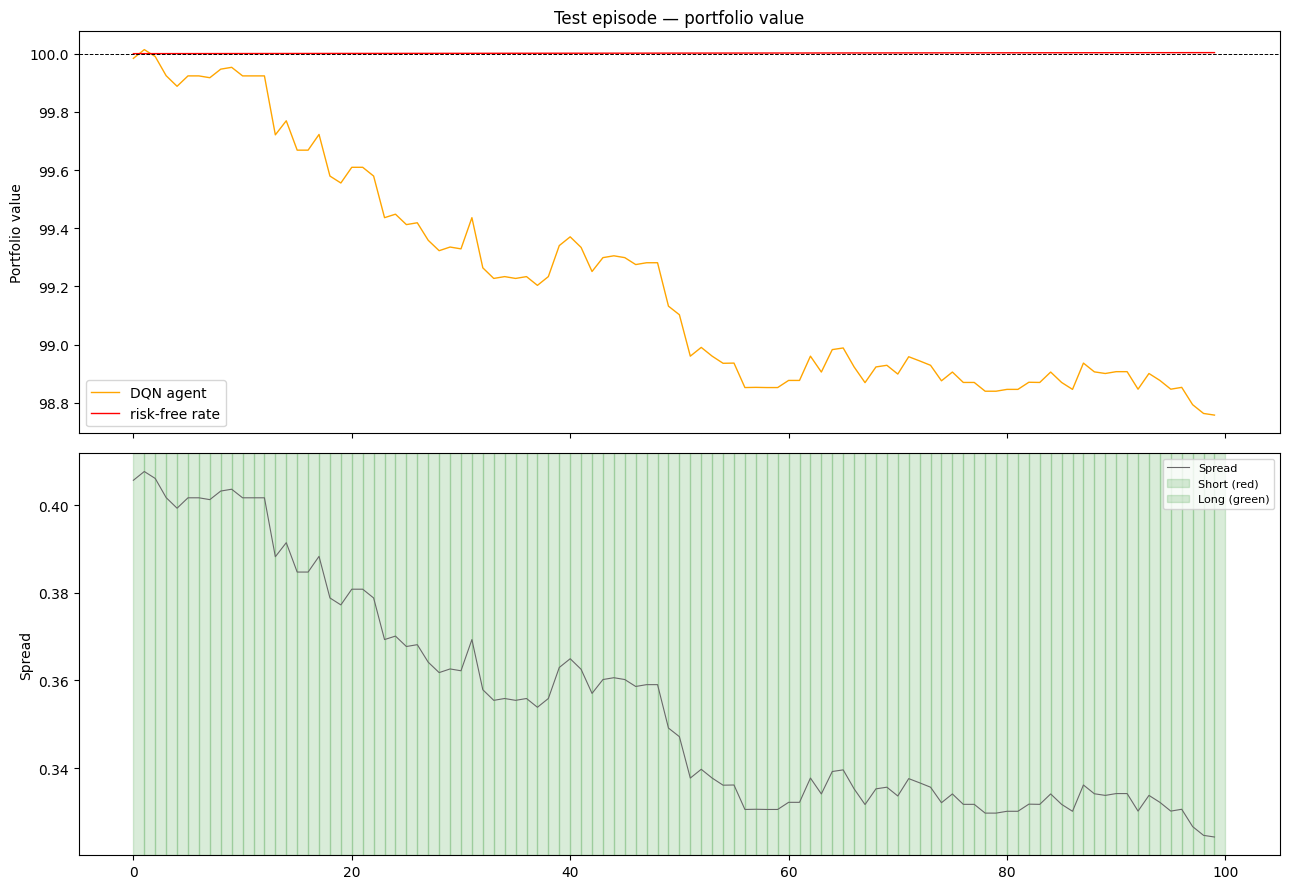

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# ── Portfolio value ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(log['portfolio_value'][:100], color='orange', linewidth=1, label='DQN agent')
ax.plot(np.linspace(100, 100*(1.04**1.86),len(log['portfolio_value']))[:100], color='red', linewidth=1, label='risk-free rate')
ax.axhline(INITIAL_CASH, color='k', linestyle='--', linewidth=0.7)
ax.set_ylabel('Portfolio value')
ax.set_title('Test episode — portfolio value')
ax.legend()

# ── Spread + z-score + position shading ──────────────────────────────
ax = axes[1]
ax.plot(log['spread'][:100], color='dimgray', linewidth=0.8, label='Spread')

# shade long / short periods
pos = log['position'][:100].values
for i in range(len(pos)):
    if pos[i] == 1:
        ax.axvspan(i, i + 1, alpha=0.15, color='green')
    elif pos[i] == -1:
        ax.axvspan(i, i + 1, alpha=0.15, color='red')

ax.set_ylabel('Spread')
ax.legend(['Spread', 'Short (red)', 'Long (green)'], fontsize=8)

plt.tight_layout()
plt.show()

In [22]:
BARS_PER_YEAR = 66_579
RF_ANNUAL     = 0.04   # 4% annualised risk-free rate

returns     = log['portfolio_value'].pct_change().dropna()
rf_per_bar  = (1 + RF_ANNUAL) ** (1 / BARS_PER_YEAR) - 1   # ~6e-7 per bar
excess      = returns - rf_per_bar

sharpe_ratio = (excess.mean() / excess.std()) * np.sqrt(BARS_PER_YEAR)
print(f'Mean excess return/bar : {excess.mean():.6e}')
print(f'Std return/bar         : {excess.std():.6e}')
print(f'Annualised Sharpe      : {sharpe_ratio:.4f}')

Mean excess return/bar : -3.593219e-06
Std return/bar         : 5.694663e-04
Annualised Sharpe      : -1.6281


In [23]:
# ── Bar frequency analysis ────────────────────────────────────────────────
# Detect the date/timestamp column and compute bars per year.

def analyse_bar_frequency(df, label=''):
    # Find the date-like column (not 'close')
    date_col = None
    for col in df.columns:
        if col.lower() != 'close':
            date_col = col
            break

    if date_col is None:
        print(f'{label}: no date column found, using integer index')
        return

    # Parse to datetime — handle both string dates and unix timestamps
    sample = df[date_col].iloc[0]
    try:
        ts = pd.to_datetime(df[date_col])
    except Exception:
        ts = pd.to_datetime(df[date_col], unit='s')

    # Median bar duration in seconds
    deltas    = ts.diff().dropna()
    median_s  = deltas.median().total_seconds()
    if median_s < 60:
        freq_str = f'{median_s:.0f}s'
    elif median_s < 3600:
        freq_str = f'{median_s/60:.1f}min'
    elif median_s < 86400:
        freq_str = f'{median_s/3600:.1f}h'
    else:
        freq_str = f'{median_s/86400:.1f}d'

    # Bars per calendar year
    years = ts.dt.year
    bars_per_year = years.value_counts().sort_index()

    print(f'\n{label}  |  total bars: {len(df):,}  |  median interval: {freq_str}')
    print(f'  {"Year":<6} {"Bars":>8}')
    for yr, cnt in bars_per_year.items():
        print(f'  {yr:<6} {cnt:>8,}')

    avg = bars_per_year.mean()
    print(f'  {"Avg":<6} {avg:>8,.0f}')
    print(f'  → annualisation factor: √{avg:.0f} = {avg**0.5:.1f}')


analyse_bar_frequency(df_a, label='Stock A (CORN)')
analyse_bar_frequency(df_b, label='Stock B (WHEAT)')


Stock A (CORN)  |  total bars: 1,065,270  |  median interval: 1.0min
  Year       Bars
  2005     29,514
  2006     42,631
  2007     60,366
  2008     70,627
  2009     71,435
  2010     83,274
  2011     96,721
  2012    114,663
  2013     80,034
  2014     66,885
  2015     67,206
  2016     68,640
  2017     50,860
  2018     60,252
  2019     70,495
  2020     31,667
  Avg      66,579
  → annualisation factor: √66579 = 258.0

Stock B (WHEAT)  |  total bars: 1,065,270  |  median interval: 1.0min
  Year       Bars
  2005     29,514
  2006     42,631
  2007     60,366
  2008     70,627
  2009     71,435
  2010     83,274
  2011     96,721
  2012    114,663
  2013     80,034
  2014     66,885
  2015     67,206
  2016     68,640
  2017     50,860
  2018     60,252
  2019     70,495
  2020     31,667
  Avg      66,579
  → annualisation factor: √66579 = 258.0


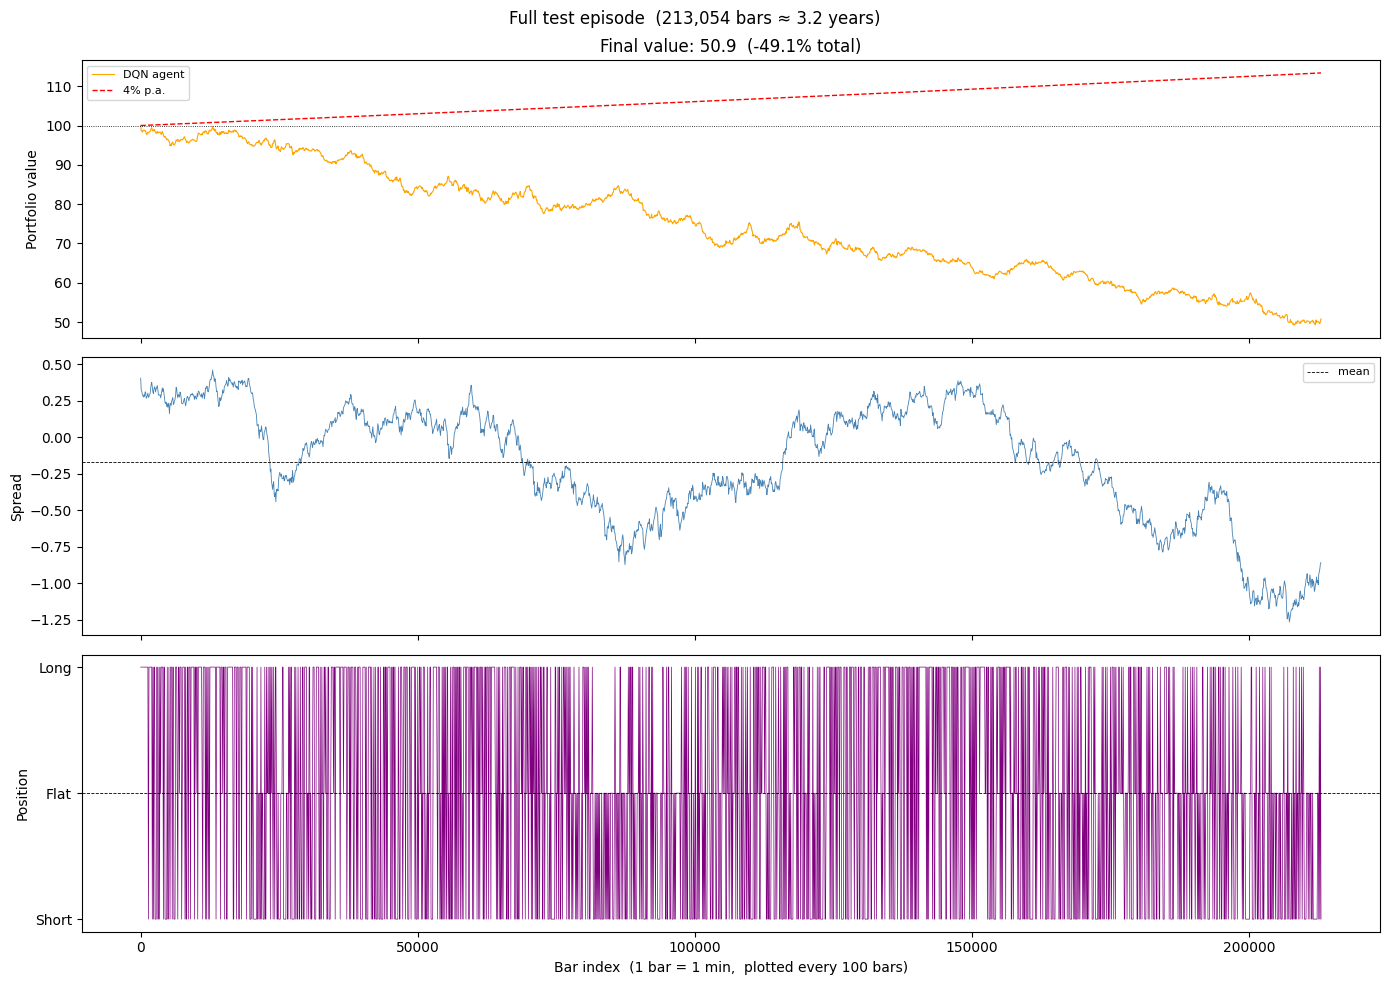

In [24]:
# ── Full test plot ────────────────────────────────────────────────────────
# Downsample for plotting (213k points is too dense to render well)
PLOT_STEP = 100   # 1 point per 100 bars ≈ every 1.7 hours

pv   = log['portfolio_value'].values
sprd = log['spread'].values
pos  = log['position'].values
t    = np.arange(len(pv))

# Risk-free benchmark: 4% annualised over 3.2 years
rf_annual  = 0.04
n_bars     = len(pv)
bars_py    = 66_579
rf_curve   = INITIAL_CASH * (1 + rf_annual) ** (t / bars_py)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Full test episode  (213,054 bars ≈ 3.2 years)', fontsize=12)

# Row 0: portfolio value
ax = axes[0]
ax.plot(t[::PLOT_STEP], pv[::PLOT_STEP],       color='orange', lw=0.8, label='DQN agent')
ax.plot(t[::PLOT_STEP], rf_curve[::PLOT_STEP], color='red',    lw=1.0, ls='--', label='4% p.a.')
ax.axhline(INITIAL_CASH, color='k', lw=0.6, ls=':')
ax.set_ylabel('Portfolio value')
ax.legend(fontsize=8)
total_ret = (pv[-1] / INITIAL_CASH - 1) * 100
ax.set_title(f'Final value: {pv[-1]:.1f}  ({total_ret:+.1f}% total)')

# Row 1: spread
ax = axes[1]
ax.plot(t[::PLOT_STEP], sprd[::PLOT_STEP], color='steelblue', lw=0.6)
ax.axhline(sprd.mean(), color='k', lw=0.6, ls='--', label='mean')
ax.set_ylabel('Spread')
ax.legend(fontsize=8)

# Row 2: position over time
ax = axes[2]
ax.plot(t[::PLOT_STEP], pos[::PLOT_STEP], color='purple', lw=0.5)
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['Short', 'Flat', 'Long'])
ax.set_ylabel('Position')
ax.set_xlabel(f'Bar index  (1 bar = 1 min,  plotted every {PLOT_STEP} bars)')

plt.tight_layout()
plt.show()

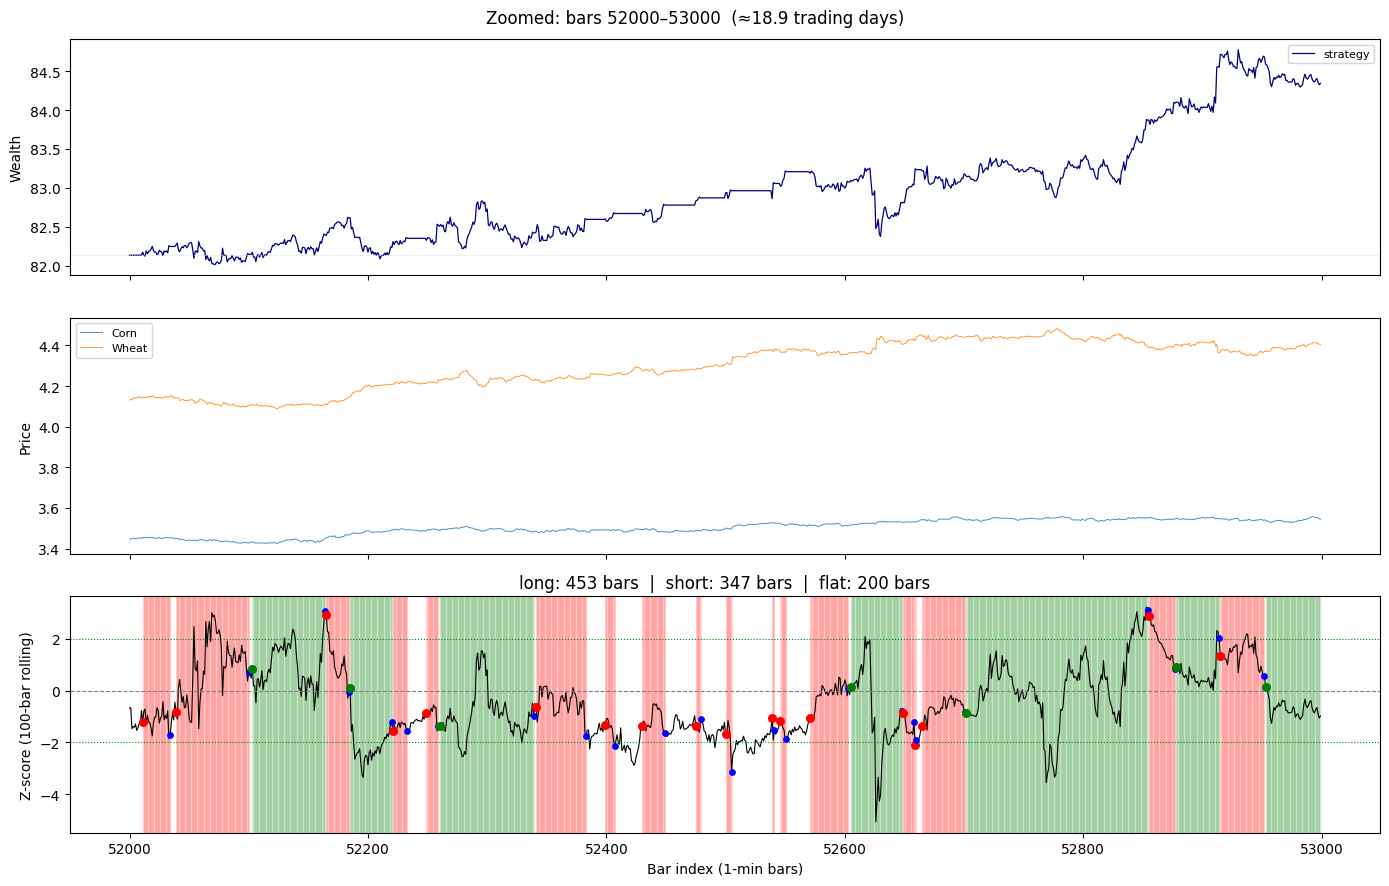

In [25]:
# ── Zoomed behaviour plot (5000 bars) ────────────────────────────────────
ZOOM_START = 52_000   # change to inspect different periods
ZOOM_END   = ZOOM_START + 1_000

pv   = log['portfolio_value'].values
sprd = log['spread'].values
pos  = log['position'].values
t    = np.arange(len(pv))

tz   = t[ZOOM_START:ZOOM_END]
pv_z = pv[ZOOM_START:ZOOM_END]
sp_z = sprd[ZOOM_START:ZOOM_END]
po_z = pos[ZOOM_START:ZOOM_END]

# Recompute 100-bar rolling z-score over full test spread (same as what agent saw)
s_series = pd.Series(sprd)
roll100  = s_series.rolling(100, min_periods=1)
z100     = ((s_series - roll100.mean()) / roll100.std().fillna(1.0).replace(0.0, 1.0)).values
z_z      = z100[ZOOM_START:ZOOM_END]

approx_days = 5000 / 66579 * 252
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle(f'Zoomed: bars {ZOOM_START}–{ZOOM_END}  (≈{approx_days:.1f} trading days)', fontsize=12)

# Row 0: portfolio value
axes[0].plot(tz, pv_z, color='navy', lw=0.9, label='strategy')
axes[0].axhline(pv_z[0], color='lightgray', lw=0.6, ls=':')
axes[0].set_ylabel('Wealth')
axes[0].legend(fontsize=8)

# Row 1: prices
ax = axes[1]
A_z = df_a_test['close'].values[ZOOM_START:ZOOM_END]
B_z = df_b_test['close'].values[ZOOM_START:ZOOM_END]
ax.plot(tz, A_z, label='Corn',  lw=0.7, alpha=0.8)
ax.plot(tz, B_z, label='Wheat', lw=0.7, alpha=0.8)
ax.set_ylabel('Price')
ax.legend(fontsize=8)

# Row 2: z-score with position shading + entry/exit dots
ax = axes[2]
ax.plot(tz, z_z, color='black', lw=0.8)
ax.axhline( 0,   color='gray',  lw=0.8, ls='--')
ax.axhline( 2.0, color='green', lw=0.8, ls=':')
ax.axhline(-2.0, color='green', lw=0.8, ls=':')

for i in range(len(po_z) - 1):
    if po_z[i] == 1:
        ax.axvspan(tz[i], tz[i+1], alpha=0.12, color='green')
    elif po_z[i] == -1:
        ax.axvspan(tz[i], tz[i+1], alpha=0.12, color='red')

for i in range(1, len(po_z)):
    if po_z[i] != po_z[i-1]:
        if po_z[i] == 1:
            ax.scatter(tz[i], z_z[i], color='green', s=30, zorder=5)
        elif po_z[i] == -1:
            ax.scatter(tz[i], z_z[i], color='red',   s=30, zorder=5)
        else:
            ax.scatter(tz[i], z_z[i], color='blue',  s=15, zorder=5)

n_long  = int(np.sum(po_z == 1))
n_short = int(np.sum(po_z == -1))
n_flat  = int(np.sum(po_z == 0))
ax.set_ylabel('Z-score (100-bar rolling)')
ax.set_xlabel('Bar index (1-min bars)')
ax.set_title(f'long: {n_long} bars  |  short: {n_short} bars  |  flat: {n_flat} bars')

plt.tight_layout()
plt.show()

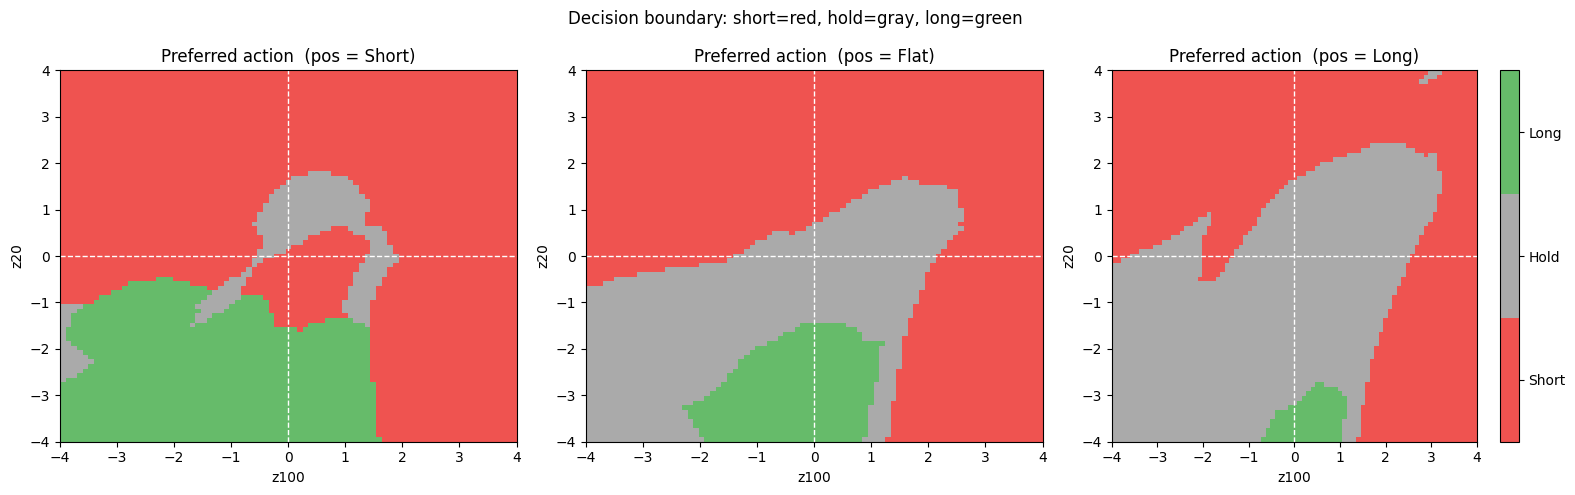

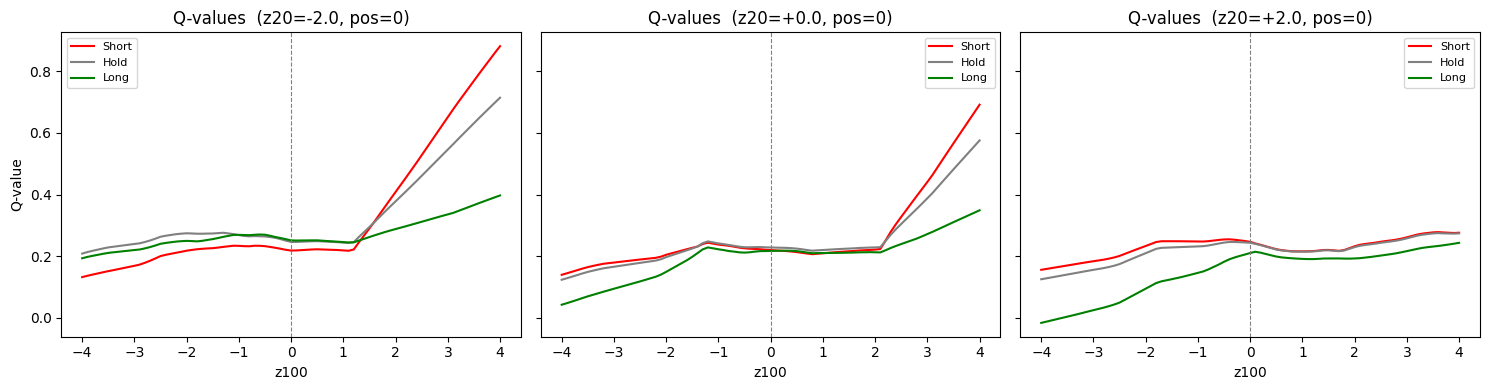

QNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [26]:
# ── Decision boundary ────────────────────────────────────────────────────
# State: [position, raw_spread, z100, z20]
# Sweep z100 × z20 with position fixed; raw_spread fixed at test mean.

z100_vals   = np.linspace(-4, 4, 81)
z20_vals    = np.linspace(-4, 4, 81)
spread_mean = float(log['spread'].mean())

agent.policy_net.eval()

def get_action_grid(pos_fixed):
    grid = np.zeros((len(z20_vals), len(z100_vals)), dtype=int)
    with torch.no_grad():
        for i, z20 in enumerate(z20_vals):
            for j, z100 in enumerate(z100_vals):
                obs = torch.tensor(
                    [pos_fixed, spread_mean, z100, z20],
                    dtype=torch.float32, device=DEVICE
                ).unsqueeze(0)
                grid[i, j] = int(agent.policy_net(obs).argmax().item())
    return grid

cmap = plt.matplotlib.colors.ListedColormap(['#ef5350', '#aaaaaa', '#66bb6a'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (pos, label) in zip(axes, [(-1, 'pos = Short'), (0, 'pos = Flat'), (1, 'pos = Long')]):
    grid = get_action_grid(pos)
    im = ax.imshow(
        grid, aspect='auto', origin='lower', cmap=cmap, vmin=-0.5, vmax=2.5,
        extent=[z100_vals[0], z100_vals[-1], z20_vals[0], z20_vals[-1]],
    )
    ax.set_xlabel('z100')
    ax.set_ylabel('z20')
    ax.set_title(f'Preferred action  ({label})')
    ax.axvline(0, color='white', lw=1, ls='--')
    ax.axhline(0, color='white', lw=1, ls='--')

cbar = plt.colorbar(im, ax=axes[-1], ticks=[0, 1, 2])
cbar.set_ticklabels(['Short', 'Hold', 'Long'])
fig.suptitle('Decision boundary: short=red, hold=gray, long=green', fontsize=12)
plt.tight_layout()
plt.show()

# ── Q-values along z100 axis at fixed z20 slices (pos=0) ────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, z20_fix in zip(axes, [-2.0, 0.0, 2.0]):
    q_vals = np.zeros((len(z100_vals), 3))
    with torch.no_grad():
        for j, z100 in enumerate(z100_vals):
            obs = torch.tensor(
                [0.0, spread_mean, z100, z20_fix],
                dtype=torch.float32, device=DEVICE
            ).unsqueeze(0)
            q_vals[j] = agent.policy_net(obs).cpu().numpy()[0]
    for k, (lbl, col) in enumerate(zip(['Short', 'Hold', 'Long'], ['red', 'gray', 'green'])):
        ax.plot(z100_vals, q_vals[:, k], label=lbl, color=col, lw=1.5)
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('z100')
    ax.set_title(f'Q-values  (z20={z20_fix:+.1f}, pos=0)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Q-value')
plt.tight_layout()
plt.show()

agent.policy_net.train()